# Unadjusted Langevin Algorithm for inverse problems in imaging

**Authors:**
* Yiming Xi

* [Julie Delon](https://github.com/judelo)
* Lucía Bouza

## Reminder on ULA

Assume that we want to sample from a target distribution $\pi \propto e^{-U}$, with $U:\mathbb{R}^d\rightarrow \mathbb{R}$ a known potential.

To this aim, we propose to use the Unadjusted Langevin Algorithm (ULA), which belongs to the family of MCMC methods, and relies on an Euler discretization of the  Langevin stochastic differential equation associated with $\pi$.
The algorithm update step reads
$$X_{k+1} = X_k - \delta \nabla U (X_k) +\sqrt{2\delta } Z_{k+1},$$
where $\delta$ is a step size and $\{Z_k\}$ is a sequence of i.i.d. $d$-dimensional standard Gaussian random variables.
It can be shown that $\{X_k\}$ is a homogeneous Markov chain.

Under some specific conditions on $U$ and $\delta$, it can be shown that the chain $\{X_k\}$ converges to its unique invariant distribution $\pi_{\delta}$, which is "close" to the target distribution $\pi \propto e^{-U}$ (the smaller $\delta$, the closer the distributions).

Mainly, the assumptions on $U$ and $\delta$ are
1. $U:\mathbb{R}^d\rightarrow \mathbb{R}$ is continuously differentiable and  such that $\nabla U$ is $L$-Lipschitz, i.e. such that
$$\forall x,y,\;\; \|\nabla U(x) - \nabla U (y)\| \le L \|x-y\|.$$
2. $U$ is strongly convex, i.e. there exists $m$ such that
$$\forall x,y \;\;  U(y) - U (x) \ge \langle\nabla U(x),y-x\rangle +\frac m 2 \|x-y\|^2.$$
3. $\delta \le \frac 1 L$.  


## Importing packages

Below are some useful packages for this notebook.

- `numpy`
- `matplotlib` (display of images and graphics)
-  `os` (interactions with the operating system)
- `time` (measure time)
- `tqdm` (shows progress)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from time import time
from tqdm import tqdm

## 1D experiment
In the following, we start by experimenting with ULA for sampling 1D distributions.
The conditions on ULA make it appropriate for distributions which are not too far from Gaussian distributions in practice.

1. Use ULA to sample the Gaussian distribution with standard deviation $\sigma=1$ and mean $\mu=0$, that has density $\frac{1}{\sqrt{2\pi}}e^{-\frac{x^2}{2}}$.
2. Starting from $X_0=0$ for instance, what is the distribution of $X_n$ after $n$ iterations of ULA?  Show that the asymptotic variance of the chain is $\frac 2 {2- \delta}$. What happens when $\delta=1$?

Write a function `Y = ULA_gauss(niter,delta,x0)` where *niter* is the number of iterations, *delta* is the parameter $\delta$ of ULA algorithm, and *x0* is the initialization. *Y* will be the sequence of samples through iterations Y=($X_0,...X_n$).

## Solutions


In [ ]:
#@title

def ULA_gauss(niter,delta,x0=0):
    Y = np.zeros(niter,)
    X = x0
    for i in range(niter):
        Z = np.random.randn()
        grad = X
        X = X - delta*grad + np.sqrt(2*delta)*Z
        Y[i] = X
    return Y, np.var(Y)

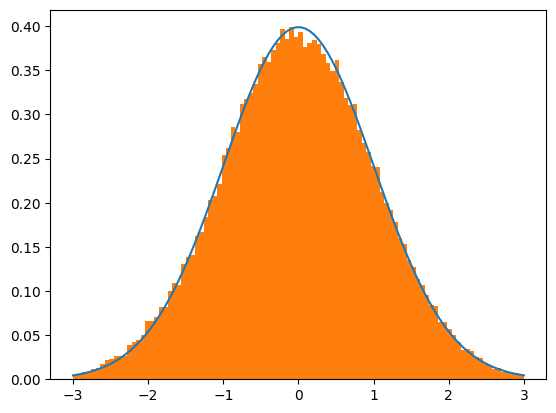

In [ ]:
# Parameters
x0 = 0
niter = int(1e5)
delta = .1

# Algorithm
Y, _ = ULA_gauss(niter,delta,x0)

# Display gauss distribution (line in blue)
x = np.linspace(-3,3,100)
y = 1/(np.sqrt(2*np.pi))*np.exp(-x**2 /2)
plt.plot(x,y)
# Display result of ULA sampling
plt.hist(Y,bins=100,range=[-3,3],density=1)
plt.show()

In [ ]:
def var_compare(delta):
  _, var1 = ULA_gauss(int(1e5),delta,x0=0)
  var2 = 2/(2-delta)
  print(var1)
  print(var2)

In [ ]:
var_compare(0.1)
print('#####')
var_compare(1)

1.0530063119227382
1.0526315789473684
#####
2.0071958600339754
2.0


## Using ULA to sample TV-L2 with blur operator A
We observe an image
$$u_b = Au_0+n$$
where the original image $u_0$ is unknown and the linear operator $A$ represents a (circular) convolution with a known kernel $h$, and $n$ represents i.i.d Gaussian noise. We wish to use ULA to sample from the distribution $\pi \propto e^{-U(u)}$ where
$$U(u) = \frac{1}{2\sigma^2}\|Au - u_b\|^2+ \lambda \mathrm{TV}(u). $$
If the blur operator $A$ is invertible (true for Gaussian blurs for instance), then the strong convexity assumption is valid. The TV term is not smooth, so we propose to use instead the Huber approximation of the total variation
$$HTV(u) = \sum_{i\in \Omega} \|\nabla u_i\|_\epsilon$$
where $$\|g\|_\epsilon = \begin{cases} \frac{\|g\|_2^2}{2\epsilon} & \text{ if } \|g\|_2 \le \epsilon \\ \|g\|_2 - \frac{\epsilon}{2} \text{ otherwise.}\end{cases}$$
$HTV(u)$ is smooth and its gradient is
$$ \nabla HTV(u)_i = \begin{cases}  -\frac{1}{\epsilon} \mathrm{div} ({\nabla u_i})  & \text{ if } \|\nabla u_i\|_2 \le \epsilon \\  -\mathrm{div} \frac{\nabla u_i}{\|\nabla u_i\|_2}\text{ otherwise.}\end{cases}$$
If we use the simplest discrete scheme to compute the gradient, then $ \nabla HTV(u)$ is $\frac 8 \epsilon$ - Lipschitz for $\epsilon \le 1$.


The ULA scheme can be written
$$X_{k+1} = X_k - \frac{\delta}{\sigma^2}(A^T A X_k - A^T u_b) - \delta \lambda \nabla HTV(X_k) +\sqrt{2\delta } Z_{k+1}.$$






## An idea for computing the gradient of $HTV(u)$

in 1D case, we have $u=(u_i)_{i=1,\cdots,N}$. Define the the gradient of $u$ as $D(u_i)=u_{i+1}-u_i$, then we have
$$HTV(U)=∑f(D(u_i))$$

\begin{align}
\frac{\partial}{\partial u_i}HTV(u)&=\frac{\partial}{\partial u_i}f(D(u_i))+\frac{\partial}{\partial u_i}f(D(u_{i-1})) \\
&=-f'(u_{i+1}-u_i)+f'(u_i-u_{i-1})
\end{align}

### 1. Create the blurry image.

For the sake of simplicity we will use in the following a uniform blur, even if it does not fulfill the invertibility condition. The matrix $A$ is never computed explicitely (it would be HUGE !), all the operations involving $A$ or $A^*$ must be written directly in the Fourier domain. For instance:  
- If $Au$ is a convolution with the kernel $h$, it can be computed as
$$\mathcal{F}^{-1} ( \hat{u}. \hat{h} )$$
with $\mathcal{F}$ the Fourier transform, $\hat{u}=\mathcal{F}(u)$, $\hat{h}=\mathcal{F}(h)$ and $\mathcal{F}^{-1}$ the inverse Fourier transform.
- $A^*u$ is a convolution with the conjugate of the kernel $h$.


Definition of convolution function and kernel.

In [ ]:
def kernel(n_row, n_col, s):
   # kernel definition (for (2*s+1, 2*s+1) uniform kernel)
   h = np.zeros((n_row,n_col))
   h[0:s+1,0:s+1] = np.ones((s+1, s+1))/(2*s+1)**2
   h[0:s+1,-s:] = np.ones((s+1, s))/(2*s+1)**2
   h[-s:,0:s+1] = np.ones((s, s+1))/(2*s+1)**2
   h[-s:,-s:] = np.ones((s, s))/(2*s+1)**2
   return h

def convol_periodic(a,b):
   return np.real(np.fft.ifft2(np.fft.fft2(a)*np.fft.fft2(b)))

We now import an image and create a blurred version with additive noise.

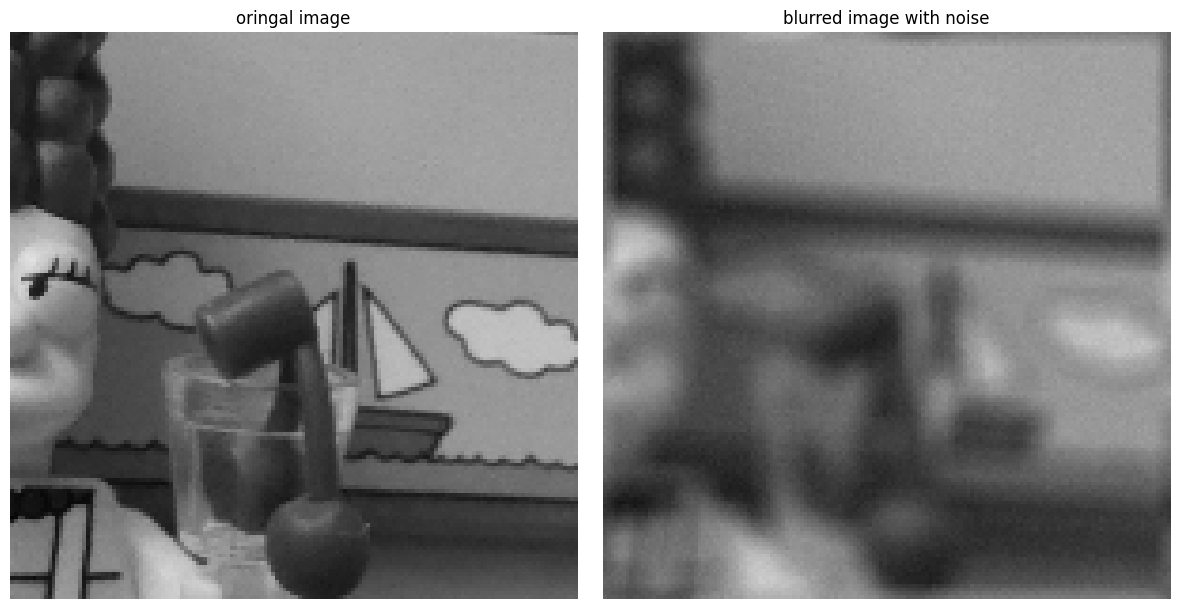

In [ ]:
# Read image
os.system("wget -nc https://raw.githubusercontent.com/storimaging/Images/main/img/simpson_nb512.png")
u = plt.imread("simpson_nb512.png")

# Crop image
u = u[100:250,100:250]

# blurred image + noise
sigma = 0.01
h = kernel(u.shape[0], u.shape[1], 4)
ub = convol_periodic(u,h) + sigma*np.random.randn(u.shape[0],u.shape[1])

# Print images
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
axes[0].set_title('oringal image')
axes[0].imshow(u,cmap='gray',vmin=0,vmax=1)
axes[0].axis('off')
axes[1].set_title('blurred image with noise')
axes[1].imshow(ub,cmap='gray',vmin=0,vmax=1)
axes[1].axis('off')
fig.tight_layout()
plt.show()

### 2.ULA deblurring

In the next cell we run the ULA algorithm.

We compute the average value of all samples after a burn-in phase.

Write a function `ula_deblurring` with the following parameters:
- ub: noisy image
- u: original image (to compute output MMSE_error)
- sigma: standard deviation of noise of the noisy image.
- delta: parameter of ULA iteration
- lambd: TV regularization parameter lambda
- epsilon: Regularization for HTV (since ULA needs differentiable potentials)
- h: kernel of convolution
- inter: interval between two saved samples
- n_iter: total number of iterations
- n_burn_in: number of iterations for the burn-in phase.

The algorithm returns:
- X_mean: The average posterior
- Xf: Last sample
- std: The posterior standard deviation
- X_samples: sequence of saved samples through iterations
- MMSE_error: Average error between X_mean and u

In [ ]:
def grad(im):
    """
    computes the gradient of the image 'im'
    """

    nr,nc=im.shape

    gx = im[:,1:]-im[:,0:-1]
    gx = np.block([gx,np.zeros((nr,1))])

    gy =im[1:,:]-im[0:-1,:]
    gy=np.block([[gy],[np.zeros((1,nc))]])
    return gx,gy

def div(cx,cy):
    """
    cy and cy are coordonates of a vector field.
    #the function computes the discrete divergence of this vector field
    """

    nr,nc=cx.shape

    ddx=np.zeros((nr,nc))
    ddy=np.zeros((nr,nc))

    ddx[:,1:-1]=cx[:,1:-1]-cx[:,0:-2]
    ddx[:,0]=cx[:,0]
    ddx[:,-1]=-cx[:,-2]

    ddy[1:-1,:]=cy[1:-1,:]-cy[0:-2,:]
    ddy[0,:]=cy[0,:]
    ddy[-1,:]=-cy[-2,:]

    d=ddx+ddy

    return d

## Solutions


In [ ]:
def grad_htv(I, eps):
    """
    This function allows to compute the gradient of the HTV energy of an image.
    Inputs:
        - I: the image
        - eps (int): regularization parameter
    """
    grad_x, grad_y = grad(I)
    norme = np.sqrt(grad_x**2 + grad_y**2)
    temp1 = -1/(eps)*div(grad_x,grad_y)
    temp2 = (-div(grad_x/(norme+1e-15), grad_y/(norme+1e-15)))
    return  temp1*(norme < eps) + temp2*(norme>=eps)


def ula_deblurring(im_blurred, im_orig, sigma, delta, lambd, epsilon, h, inter= 10, n_iter = 10000, n_burn_in = 1000):
    """
    Inputs:
        - im_blurred: noisy image
        - im_orig: original image (to compute output MMSE_error)
        - sigma: standard deviation of noise of noisy image.
        - delta: parameter of ULA iteration
        - lambd: TV regularization parameter lambd
        - epsilon: Regularization for HTV (since ULA needs differentiable potentials)
        - h: kernel of convolution
        - inter: Interval to save samples
        - n_iter: Total number of iterations
        - n_burn_in: Number of iterations for the burn-in phase.
    Outputs:
        - X_mean: The average posterior
        - Xf: Last sample
        - std: The posterior std
        - X_samples: sequence of samples through iterations
        - MMSE_error: Average error between X_mean and u
    """

    # Initializations
    n_Rows, n_Col = im_blurred.shape
    samples = np.zeros((n_Rows, n_Col,int(n_iter/inter)))
    X_mean = np.copy(im_blurred)
    X_2 = np.zeros((n_Rows, n_Col))
    MMSE_error = []
    X = np.zeros((n_Rows, n_Col)) # Markov chain initialization

    # Conjugate of the kernel h
    h_fft = np.fft.fft2(h)
    hc_fft = np.conj(h_fft)
    hc = np.fft.ifft2(hc_fft)

    for i in tqdm(range(n_iter)):
        # Gradient of the potential
        Z = np.random.randn(n_Rows, n_Col)
        ATA_x = np.real(np.fft.ifft2((hc_fft*h_fft)*np.fft.fft2(X)))
        AT_y = np.real(np.fft.ifft2(hc_fft*np.fft.fft2(im_blurred)))
        grad = (ATA_x- AT_y)/sigma**2 + lambd*grad_htv(X,epsilon)

        # ULA step
        X = X - delta*grad + np.sqrt(2*delta)*Z

        # Keep samples
        if (i%inter==0):
            samples[:,:,int(i/inter)] = np.copy(X)

        # Compute mean of X, and mean of X**2
        if i>=n_burn_in:
            i_b = i - n_burn_in#
            X_mean = i_b/(i_b+1)*X_mean + 1/(i_b+1)*X
            X_2 = i_b/(i_b+1)*X_2 + 1/(i_b+1)*(X**2)
            MMSE_error = MMSE_error + [1/(n_Rows*n_Col)*np.sqrt(np.sum((X_mean - im_orig)**2))]

    # Variance computation
    var = X_2 - X_mean**2
    std = np.sqrt(var*(var>=0))

    return X_mean, X, std, samples, MMSE_error,



In [ ]:
import math
def PSNR(im_0, im_rest):
    """
    This function allows to compute the PSNR.
    Inputs:
        -im_0: the original image
        -im_rest: the restored image
    Output:
        -the PSNR
    """
    N = im_0.shape[0]
    M = im_0.shape[1]
    EQM = np.linalg.norm(im_0 - im_rest, 'fro')**2/N/M

    return -10*math.log10(EQM)

In [ ]:
# Parameters for ULA
lambd = 30
epsilon = .01
L = 1/sigma**2 + 8*lambd/epsilon # Lipschitz constant
delta = 1/L # step-size
inter = 10 # interval between samples that are kept in the file X_samples
n_iter = int(2e4)
n_burn_in = int(0.1*n_iter)

# ULA algorithm
t1 = time()
X_mean, Xf, std, X_samples, MMSE_error = ula_deblurring(ub, u, sigma, delta, lambd, epsilon, h, inter, n_iter, n_burn_in)
print("\nTime spent ULA: ",time()-t1)


100%|██████████| 20000/20000 [01:43<00:00, 192.69it/s]


Time spent ULA:  103.8078122138977


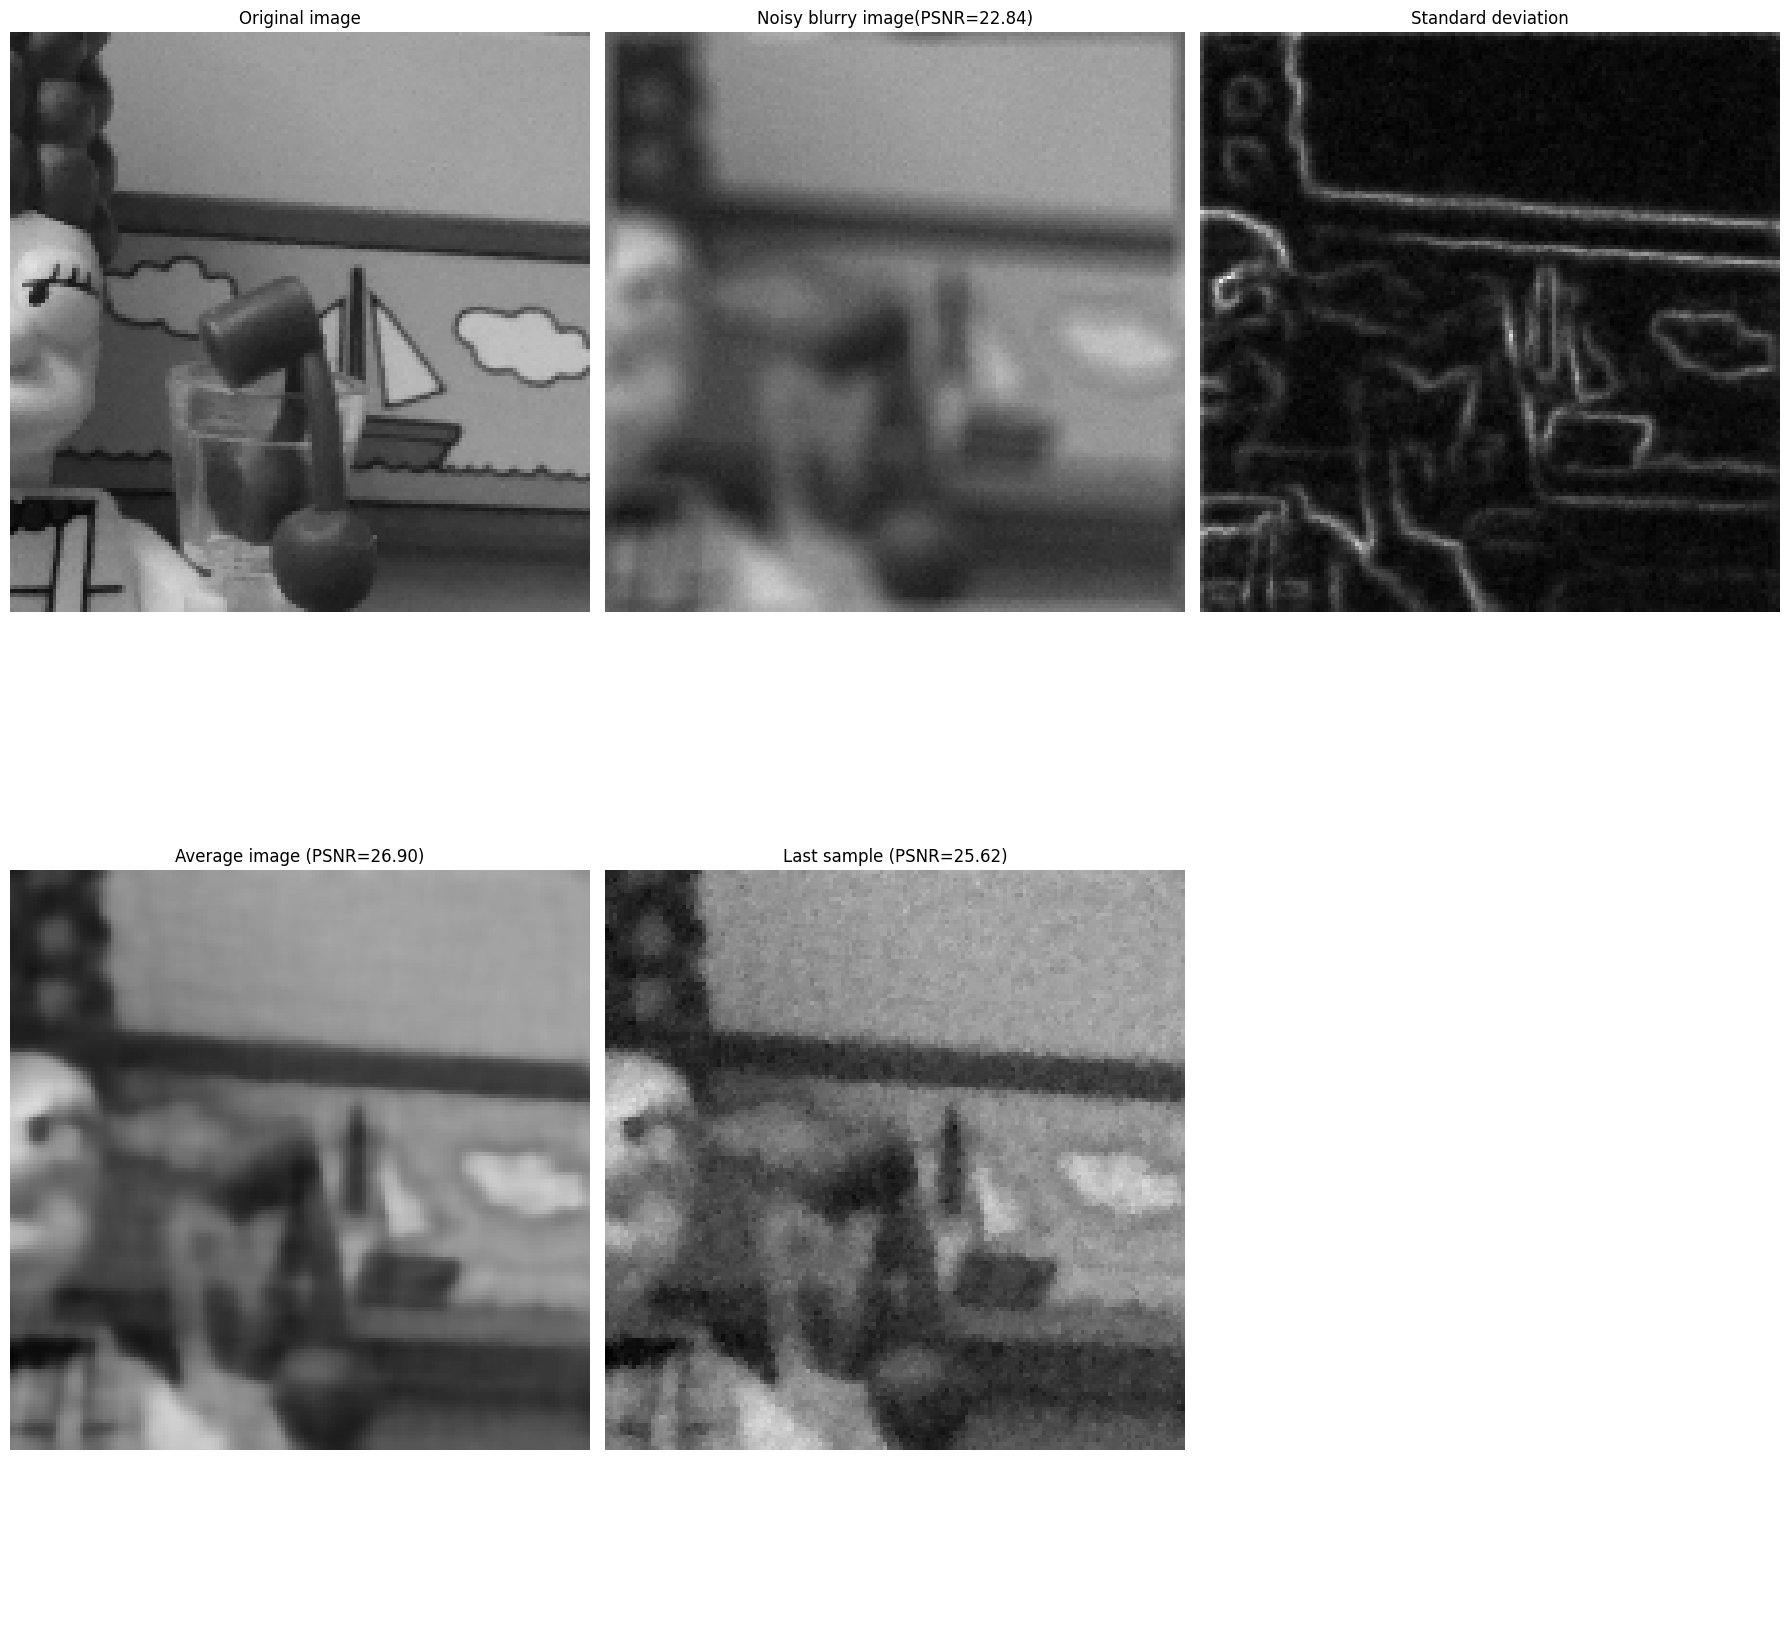

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 18))
axes[0][0].set_title('Original image')
axes[0][0].imshow(u,cmap='gray',vmin=0,vmax=1)
axes[0][0].axis('off')
axes[0][1].set_title('Noisy blurry image(PSNR={:.2f})'.format(PSNR(u, ub)))
axes[0][1].imshow(ub,cmap='gray',vmin=0,vmax=1)
axes[0][1].axis('off')
axes[0][2].set_title('Standard deviation')
axes[0][2].imshow(std,cmap='gray')
axes[0][2].axis('off')
axes[1][0].set_title('Average image (PSNR={:.2f})'.format(PSNR(u, X_mean)))
axes[1][0].imshow(X_mean,cmap='gray',vmin=0,vmax=1)
axes[1][0].axis('off')
axes[1][1].set_title('Last sample (PSNR={:.2f})'.format(PSNR(u, Xf)))
axes[1][1].imshow(Xf,cmap='gray',vmin=0,vmax=1)
axes[1][1].axis('off')
axes[1][2].axis('off')
fig.tight_layout()

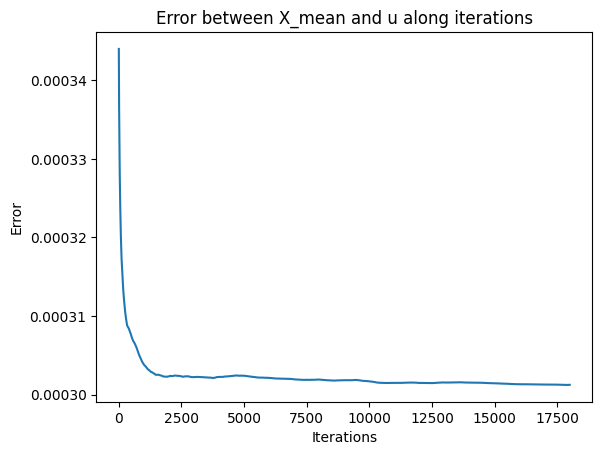

In [ ]:
plt.plot(MMSE_error)
plt.title('Error between X_mean and u along iterations')
plt.xlabel('Iterations')
plt.ylabel('Error')
plt.show()